# PF-5039: Semana 04 — Tarea Programada (Entrega en 7 días)
## Análisis Morfométrico Avanzado: Pipeline de Drepanocitosis y Conteo Celular

**Estudiantes:**
- Franco Castro Chaves, C01886
- Carolina Masis Calvo, A12127
- Emily Chacón Araya, C02047

**Profesor:** Dr. rer. nat. Francisco Siles Canales  
**Universidad de Costa Rica (UCR)** — PRIS-Lab / 2026-II

---
### Instrucciones Generales:
1. Complete los bloques señalados con `# === TODO (Estudiante) ===`.
2. Justifique sus respuestas en las celdas de Markdown correspondientes.
3. Verifique que todas las celdas se ejecuten de forma secuencial sin errores.
4. Exporte este cuaderno completamente ejecutado y genere los artefactos solicitados.

In [159]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches
from skimage import measure, color, segmentation
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'font.sans-serif': 'DejaVu Sans'})
PRIS_NAVY = '#0B1634'
PRIS_RED  = '#B82A3F'
PRIS_GOLD = '#E9C964'

def cargar_imagen(nombre, flags=cv2.IMREAD_GRAYSCALE):
    rutas = [
        Path(f"../../Imagenes_Ejemplo/{nombre}"),
        Path(f"../Imagenes_Ejemplo/{nombre}"),
        Path(rf"c:\Users\siles\Desktop\PF-5039 Análisis de imágenes\2026-II\Imagenes_Ejemplo\{nombre}"),
    ]
    for p in rutas:
        if p.exists():
            return cv2.imdecode(np.fromfile(str(p), dtype=np.uint8), flags)
    return None

print("[OK] Entorno listo.")

[OK] Entorno listo.


---
## Ejercicio 1: Implementación Manual del Algoritmo Two-Pass CCL *(Reto Avanzado)*

**Objetivo:** Comprender en profundidad el algoritmo de componentes conectados mediante su implementación desde cero.

1. Implemente en Python la clase `UnionFind` con operaciones `make_set`, `find` (con compresión de caminos) y `union` (por rango).
2. Implemente la función `two_pass_ccl(binary_img, connectivity=8)`:
   - **Pasada 1 (Raster scan):** Asigne etiquetas provisionales examinando los vecinos causales y registre colisiones con `union()`.
   - **Pasada 2:** Resuelva las equivalencias asignando la etiqueta canónica compactada a cada píxel.
3. Verifique su algoritmo con una imagen sintética pequeña ($8 \times 8$) con al menos 3 componentes y compare el conteo con `cv2.connectedComponents`.

In [160]:
# Resolución ejercicio 1: Two-Pass CCL + Union-Find.

# Paso 1: UnionFind - Para llevar la cuenta de qué etiquetas representan el mismo componente relacionado, aunque inicialmente se les hayan asignado
# etiquetas distintas.
class UnionFind:
    """Estructura Union-Find con compresión de caminos y unión por rango."""

    def __init__(self):
        self.parent = {}
        self.rank = {}
    def make_set(self, x):

# Paso 1.1: Make_Set - Entonces, cuando aparece una etiqueta nueva, se registra inicialmente en su propio grupo.
        self.parent[x] = x
        self.rank[x] = 0
    def find(self, x):

# Paso 1.2: Find - Para saber a qué grupo pertenece una etiqueta, se sigue el rastro hasta encontrar su raíz.
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    def union(self, x, y):

# Paso 1.3: Union - Se unen dos grupos cuando sus etiquetas pertenecen al mismo componente relacionado.
        raiz_x = self.find(x)
        raiz_y = self.find(y)
        if raiz_x == raiz_y:
            return
        if self.rank[raiz_x] < self.rank[raiz_y]:
            self.parent[raiz_x] = raiz_y
        elif self.rank[raiz_x] > self.rank[raiz_y]:
            self.parent[raiz_y] = raiz_x
        else:
            self.parent[raiz_y] = raiz_x
            self.rank[raiz_x] += 1



# Paso 2: def two_pass_ccl - Para recorrer la imagen binaria y etiquetar con una etiqueta única a los componentes conectados. 
def two_pass_ccl(binary_img, connectivity=8):
    """Etiquetado de componentes conectados en dos pasadas."""

# Paso 2.1: Aquí se preparan las variables necesarias para realizar el etiquetado. 
    H, W = binary_img.shape                                             # Dimensiones de la imagen.
    etiquetas_prov = np.zeros((H, W), dtype=np.int32)                   # Etiquetas provisionales que se irán asignando a cada célula encontrada.
    uf = UnionFind()                                                    # Estructura Union_Find.
    next_label = 0                                                      # Contador de etiquetas que se van a ir asignando a cada célula encontrada.

# Paso 2.2: Aquí se definen los vecinos ya procesados que se revisarán para cada píxel, según se utilice conectividad 4 u 8,
# en donde conectividad 8 son básicamente más direcciones (diagonal, horizontal y vertical), mientras que conectividad 4 solo revisa horizontal y vertical).
    if connectivity == 8:
        vecinos_causales = [(-1, -1), (-1, 0), (-1, 1), (0, -1)]
    elif connectivity == 4:
        vecinos_causales = [(-1, 0), (0, -1)]
    else:
        raise ValueError("connectivity debe ser 4 u 8")

# Paso 2.3: Primera pasada. Se recorre la imagen píxel por píxel para asignar etiquetas provisionales. Si se encuentran etiquetas diferentes que pertenecen
# al mismo componente conectado, su equivalencia se registra con union().
    for y in range(H):                                                 # Se recorre la imagen píxel por píxel.
        for x in range(W):                                             
            if binary_img[y, x] == 0:                                  # Si el píxel es fondo, se continúa.
                continue

            etiquetas_vecinas = []                                     # Se buscan las etiquetas de los vecinos ya procesados.
            for dy, dx in vecinos_causales:
                ny, nx = y + dy, x + dx
                if 0 <= ny < H and 0 <= nx < W and etiquetas_prov[ny, nx] > 0:
                    etiquetas_vecinas.append(etiquetas_prov[ny, nx])

            if not etiquetas_vecinas:                                  # Si ningún vecino tiene etiqueta, se crea una nueva etiqueta provisional.
                next_label += 1
                uf.make_set(next_label)
                etiquetas_prov[y, x] = next_label
            else:                                                      # Si existen vecinos etiquetados, se toma la etiqueta menor 
                etiqueta_min = min(etiquetas_vecinas)                  # y se registran las equivalencias con Union-Find.
                etiquetas_prov[y, x] = etiqueta_min
                for e in etiquetas_vecinas:
                    uf.union(etiqueta_min, e)

# Paso 2.4: Segunda pasada. Se reemplazan las etiquetas provisionales por etiquetas finales,
# de manera que cada componente conectado tenga una única etiqueta.
    raiz_a_canonica = {}
    contador = 0
    etiquetas_final = np.zeros((H, W), dtype=np.int32)
    for y in range(H):                                                # Se vuelve a recorrer toda la imagen.
        for x in range(W):
            if etiquetas_prov[y, x] == 0:                             # Si el píxel es fondo, se continúa con el siguiente.
                continue
            raiz = uf.find(etiquetas_prov[y, x])                      # Se busca la raíz de la etiqueta provisional usando Union-Find.
            if raiz not in raiz_a_canonica:                           # Si es una raíz nueva, se le asigna una etiqueta final.
                contador += 1
                raiz_a_canonica[raiz] = contador
            etiquetas_final[y, x] = raiz_a_canonica[raiz]             # Se asigna al píxel su etiqueta final.

# Paso 2.5: Se devuelve la imagen con las etiquetas finales y el número total de componentes conectados encontrados.
    return etiquetas_final, contador



# Paso 3: Se comprueba que la función manual funciona bien con una imagen sintética, y se compara el resultado con cv2.connectedComponents de OpenCV.
# Se crea una imagen binaria de prueba de 8x8 con tres componentes conectados separados.
test_img = np.zeros((8, 8), dtype=np.uint8)
test_img[1:3, 1:3] = 1
test_img[4:6, 4:6] = 1
test_img[1:3, 5:7] = 1

# Paso 3.1: Se aplica la implementación manual como la de OpenCV para comparar la cantidad de componentes encontrados.
etiquetas_mias, n_mio = two_pass_ccl(test_img, connectivity=8)
n_cv, etiquetas_cv = cv2.connectedComponents(test_img, connectivity=8)

# Paso 3.2: Se comparan los resultados.
print(f"1. Componentes detectados con implementación manual: {n_mio}")
print(f"2. Componentes detectados con cv2.connectedComponents: {n_cv - 1}")         # OpenCV incluye el fondo como una etiqueta, por eso se resta 1.
assert n_mio == n_cv - 1, "El conteo no coincide con OpenCV"
print("3. La implementación manual coincide con OpenCV.")

1. Componentes detectados con implementación manual: 3
2. Componentes detectados con cv2.connectedComponents: 3
3. La implementación manual coincide con OpenCV.


---
## Ejercicio 2: Pipeline de Detección de Drepanocitos

**Contexto Clínico:** La drepanocitosis (anemia falciforme) es una hemoglobinopatía genética caracterizada por eritrocitos con forma de hoz o media luna. En un análisis de frotis sanguíneo automatizado, es crucial distinguir entre eritrocitos normales (**discocitos**) y patológicos (**drepanocitos**).

**Instrucciones:**
1. Genere un frotis sintético de $500 \times 700$ píxeles con 20 discocitos circulares ($r \in [18, 26]$) y 8 drepanocitos alargados (elipses con semieje mayor $a \in [28, 42]$ y menor $b \in [7, 12]$) con orientaciones aleatorias.
2. Binarice con el método de **Otsu** y aplique una apertura morfológica con kernel elíptico $3 \times 3$.
3. Etiquete y extraiga propiedades morfométricas con `skimage.measure.regionprops`.
4. Clasifique cada eritrocito usando la **Excentricidad**: **Discocito** ($e < 0.60$) vs **Drepanocito** ($e \geq 0.60$).
5. Visualice los eritrocitos detectados coloreando discocitos en verde y drepanocitos en rojo, y reporte el Índice de Falciformación ($IF = \frac{N_{\text{sickle}}}{N_{\text{total}}} \times 100\%$).

Número de células detectadas: 28
Discocitos (e < 0.60): 20
Drepanocitos (e >= 0.60): 8
Índice de Falciformación (IF): 28.6%


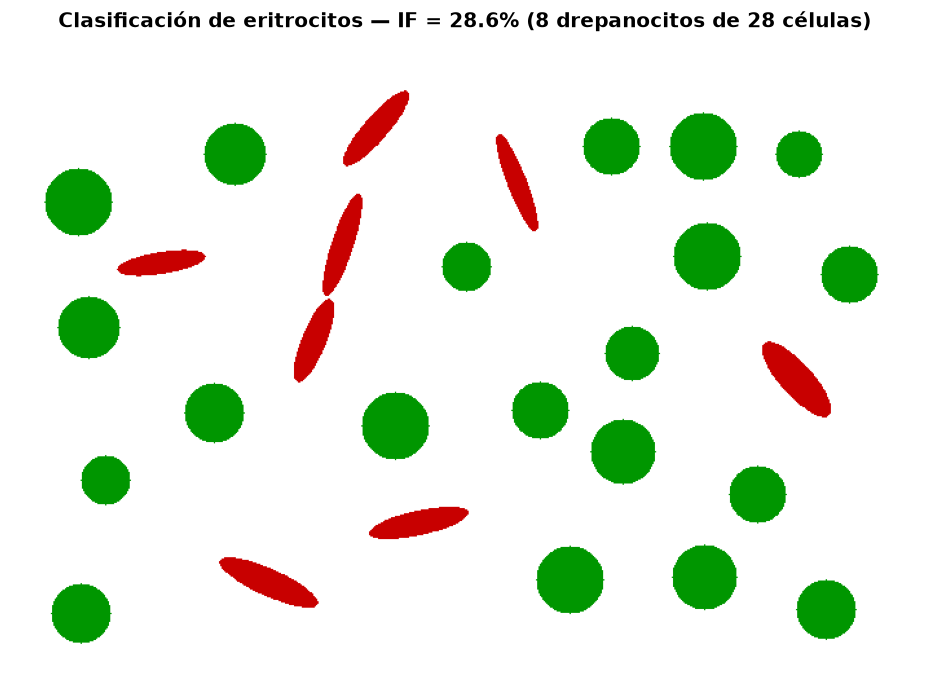

In [161]:
# Resolución ejercicio 2.

# Paso 1: Colocación aleatoria de las células evitando que se traslapen entre sí.
distancia_minima = 70 
max_intentos = 1000     
posiciones = []
intentos = 0
while len(posiciones) < 28 and intentos < max_intentos:
    intentos += 1
    centro_x = np.random.randint(50, 650)
    centro_y = np.random.randint(50, 450)
    valida = True
    for x_anterior, y_anterior in posiciones:       # Aquí se comprueba que la nueva posición esté alejada de las posiciones que ya fueron aceptadas.
        distancia = np.sqrt((centro_x - x_anterior)**2 + (centro_y - y_anterior)**2)
        if distancia < distancia_minima:
            valida = False
            break
    if valida:
        posiciones.append((centro_x, centro_y))
assert len(posiciones) == 28, "No se lograron colocar las 28 células, revisar distancia_minima"   # Se verifica que se hayan generado las 28 posiciones.
np.random.shuffle(posiciones)                            # Se desordenan para que los discocitos y drepanocitos no queden juntos.


# Paso 2: Construcción de la imagen del frotis, en escala de grises.
frotis = np.zeros((500, 700), dtype=np.uint8)

for i in range(20):                                  # Se dibujan los 20 discocitos en las primeras 20 posiciones.
    centro_x, centro_y = posiciones[i]
    radio = np.random.randint(18, 27)
    cv2.circle(frotis, (centro_x, centro_y), radio, 255, -1)

for i in range(20, 28):                            # Se dibujan los 8 drepanocitos en las 8 posiciones restantes.
    centro_x, centro_y = posiciones[i]
    semieje_mayor = np.random.randint(28, 43)
    semieje_menor = np.random.randint(7, 13)
    angulo = np.random.randint(0, 180)
    cv2.ellipse(frotis, (centro_x, centro_y), (semieje_mayor, semieje_menor), angulo, 0, 360, 255, -1)


# Paso 3: Binarización de Otsu + apertura morfológica.
_, mascara_binaria = cv2.threshold(frotis, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel_eliptico = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
mascara_limpia = cv2.morphologyEx(mascara_binaria, cv2.MORPH_OPEN, kernel_eliptico)


# Paso 4: Etiquetado de las células y extracción de excentricidad.
etiquetas = measure.label(mascara_limpia // 255, connectivity=2)
propiedades = measure.regionprops(etiquetas)

print(f"Número de células detectadas: {len(propiedades)}")


# Paso 5: Clasificación por excentricidad y cálculo del Índice de Falciformación (IF).
discocitos = []
drepanocitos = []

for celula in propiedades:
    if celula.eccentricity < 0.60:
        discocitos.append(celula)
    else:
        drepanocitos.append(celula)

total_celulas = len(propiedades)                     # Se calcula el Índice de Falciformación.
IF = len(drepanocitos) / total_celulas * 100

print(f"Discocitos (e < 0.60): {len(discocitos)}")
print(f"Drepanocitos (e >= 0.60): {len(drepanocitos)}")
print(f"Índice de Falciformación (IF): {IF:.1f}%")


# Paso 6: Visualización final clasificada, sobre fondo blanco (verde: discocitos, rojo: drepanocitos).
imagen_clasificada = np.full((500, 700, 3), 255, dtype=np.uint8)

VERDE = (0, 150, 0)
ROJO = (200, 0, 0)

for celula in propiedades:
    color_celula = VERDE if celula.eccentricity < 0.60 else ROJO
    filas_px, columnas_px = celula.coords[:, 0], celula.coords[:, 1]
    imagen_clasificada[filas_px, columnas_px] = color_celula

plt.figure(figsize=(10, 7))
plt.imshow(imagen_clasificada)
plt.title(f"Clasificación de eritrocitos — IF = {IF:.1f}% "
          f"({len(drepanocitos)} drepanocitos de {total_celulas} células)",
          fontweight='bold')
plt.axis('off')
plt.show()

**Conclusión del Ejercicio 2:**
1. ¿Es el umbral $e = 0.60$ adecuado para esta población celular? ¿Qué ocurriría en presencia de eritrocitos sobrepuestos (rouleaux)?

El umbral $e = 0.60$ resultó adecuado para esta población, ya que produjo la separación esperada entre los 20 discocitos y los 8 drepanocitos. 
Esto se debe a que las geometrías utilizadas para generar ambas poblaciones presentan una separación marcada en su excentricidad. 
Sin embargo, en presencia de eritrocitos sobrepuestos, el algoritmo de etiquetado los uniría en una sola región conectada de forma alargada e irregular. Eso haría que un grupo de discocitos normales pero pegados se clasifique erróneamente como un solo drepanocito, inflando artificialmente el Índice de Falciformación y dando un diagnóstico más grave del que corresponde en realidad. Esto se comprobó reduciendo varias veces la distancia mínima entre células y volviendo a correr el pipeline completo, con 60 píxeles el Índice de Falciformación se mantuvo en 28.6%, con 50 píxeles subió a 29.6%, con 40 píxeles llegó a 42.9%, y con 30 píxeles fue de 38.9%. El Índice de Falciformación aumentó conforme se fue reduciendo la distancia mínima, ya que varias células quedaron pegadas entre sí y el algoritmo de etiquetado las fusionó en una sola región cada vez que se tocaban, contando así menos células de las que en realidad había. Esto confirma que, en un contexto clínico real, la presencia de eritrocitos sobrepuestos (rouleaux) podría producir un diagnóstico de severidad mayor al real.

---
## Ejercicio 3: Calibración Espacial y Especificaciones de Equipos Biomédicos *(Slide 30)*

En la lámina 30 de la lección se presentaron órdenes de magnitud típicos de resolución espacial ($s$ en $\mu\text{m/px}$) para microscopios ópticos ($4\times, 10\times, 40\times, 100\times$), TC axial ($0.3-0.5\,\text{mm/px}$), RM 3T ($0.8-1.0\,\text{mm/px}$) y retinografía ($5-10\,\mu\text{m/px}$).

**Instrucciones:**
1. Seleccione e investigue en la literatura técnica o manuales de fabricantes una modalidad de imagen biomédica distinta (por ejemplo: Tomografía de Coherencia Óptica - OCT, Micro-TC preclínica, o Microscopía de Super-Resolución STED/STORM).
2. Indique en un diccionario de Python: nombre del equipo/modalidad, tamaño de píxel/vóxel nominal ($s$ en $\mu\text{m}$), campo de visión típico (FOV), y calcule el área física real en $\mu\text{m}^2$ de una estructura celular segmentada de $1\,250$ píxeles.
3. Imprima el reporte de calibración formateado con unidades físicas.

In [162]:
# Resolución ejercicio 3.

# 1. Definir los parámetros del equipo biomédico investigado.
equipo_info = {
    'modalidad': 'Micro-Tomografía Computarizada Preclínica (Micro-CT)',
    'fabricante_modelo': 'Bruker SKYSCAN 1276 CMOS Edition',
    'tamano_pixel_um': 2.8,                                         # Menor tamaño de píxel: 2.8 µm.
    'fov_tipico': '75 mm de diámetro x 310 mm de longitud',
    'aplicacion_preclinica': 'Estudios in vivo de hueso, vasculatura, pulmón y tejido blando en animales pequeños'
}

# 2. Calcular el área física de una estructura segmentada de 1250 píxeles.
area_pixeles = 1250
s_um = equipo_info['tamano_pixel_um']
area_fisica_um2 = area_pixeles * (s_um ** 2)

# 3. Imprimir la ficha técnica y el cálculo del área física.
print("Ficha técnica del equipo biomédico:")
print()
print(f"Modalidad: {equipo_info['modalidad']}")
print(f"Equipo: {equipo_info['fabricante_modelo']}")
print(f"Tamaño de píxel nominal (s): {equipo_info['tamano_pixel_um']} µm/px")
print(f"Campo de visión típico (FOV): {equipo_info['fov_tipico']}")
print(f"Aplicación: {equipo_info['aplicacion_preclinica']}")
print()
print(f"Área segmentada: {area_pixeles} px")
print(f"Área física real: {area_fisica_um2:.1f} µm²")

Ficha técnica del equipo biomédico:

Modalidad: Micro-Tomografía Computarizada Preclínica (Micro-CT)
Equipo: Bruker SKYSCAN 1276 CMOS Edition
Tamaño de píxel nominal (s): 2.8 µm/px
Campo de visión típico (FOV): 75 mm de diámetro x 310 mm de longitud
Aplicación: Estudios in vivo de hueso, vasculatura, pulmón y tejido blando en animales pequeños

Área segmentada: 1250 px
Área física real: 9800.0 µm²


<img src="imagenes/skyscan_galeria.png" width="1200">

## Referencias bibliográficas

[1] Bruker Corporation, "SKYSCAN 1276 in vivo micro-CT system," Bruker.com. [Online]. Available: https://www.bruker.com/en/products-and-solutions/preclinical-imaging/micro-ct/skyscan-1276.html. [Accessed: 17-Sep-2026].

[2] Micro Photonics Inc., "SkyScan 1276," Microphotonics.com. [Online]. Available: https://www.microphotonics.com/products/skyscan-1276/. [Accessed: 17-Sep-2026].


---
## Ejercicio 4: Análisis de Morfometría Multi-Escala

**Objetivo:** Comprender el efecto de la resolución espacial y la discretización sobre los descriptores de forma (paradoja de la discretización).

1. Genere una imagen sintética de 5 células circulares idénticas (radio nominal $r = 25$ píxeles).
2. Reduzca progresivamente la escala al 100%, 75%, 50%, 25% y 12% usando `cv2.resize` con interpolación por área (`cv2.INTER_AREA`).
3. Calcule la **Compacticidad Media** ($C = \frac{4\pi A}{P^2}$) en cada nivel de resolución.
4. Grafique la curva de Compacticidad vs. Nivel de Resolución (%) y muestre las imágenes redimensionadas.
5. Determine el límite crítico de resolución y área mínima a partir del cual el cálculo de compacticidad deja de ser confiable ($C < 0.90$).

Resultados de morfometría multi-escala
  Resolución      C media      Área media     Área mínima
       100%       0.9068         1961.00         1961.00
        75%       0.9329         1109.00         1109.00
        50%       0.9773          500.00          500.00
        25%       1.0780          121.00          121.00
        12%       1.2596           28.40           28.00

Todas las resoluciones presentan C >= 0.90.


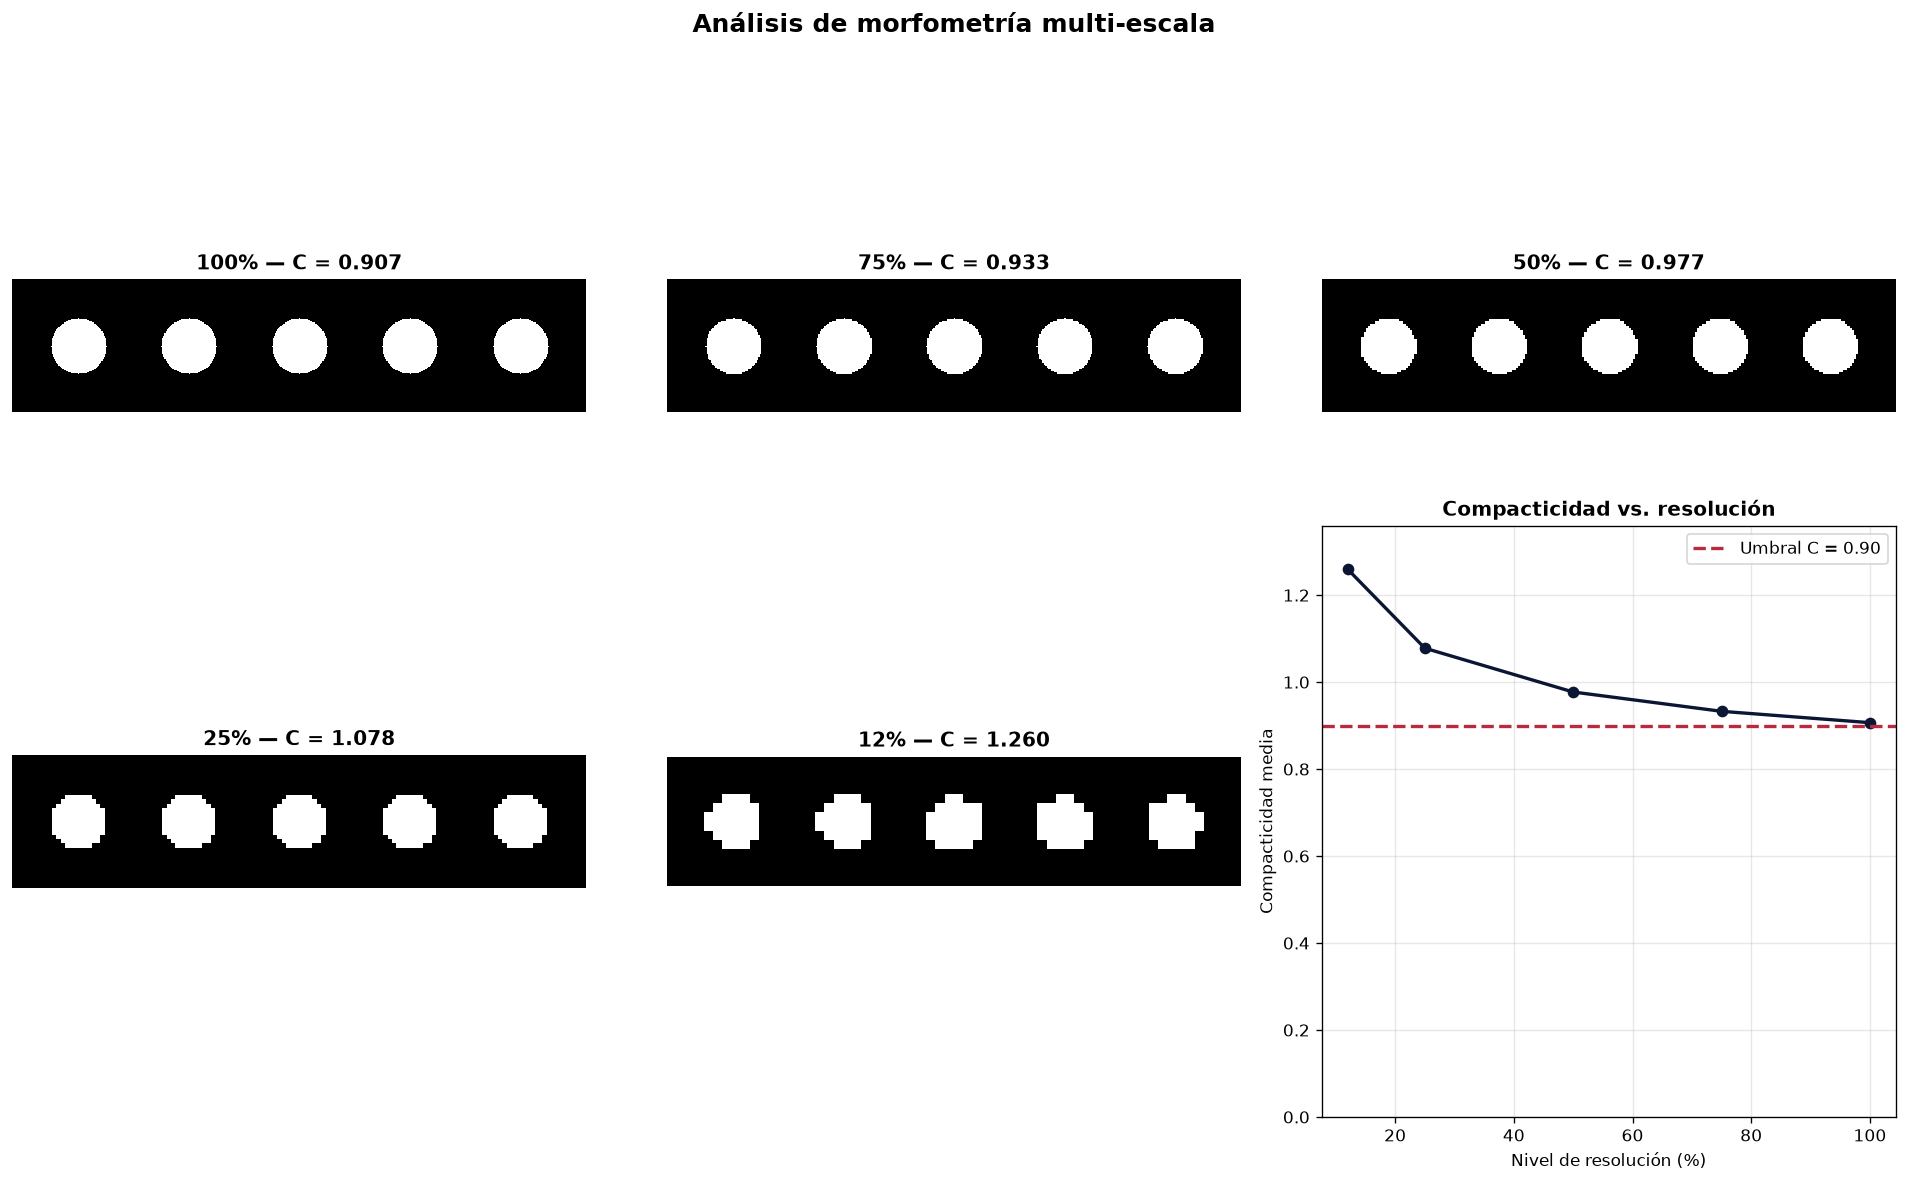

In [163]:
# Resolución del ejercicio 4.

# Paso 1. Generar una imagen base con cinco células circulares idénticas.
alto, ancho = 120, 520                           # Dimensiones de la imagen.
radio = 25                                       # Radio de cada célula.
centros = [                                      # Centros de las cinco células.
    (60, 60),
    (160, 60),
    (260, 60),
    (360, 60),
    (460, 60)
]

imagen_base = np.zeros((alto, ancho), dtype=np.uint8)   # Se crea una imagen con fondo negro y se dibujan las cinco células como círculos blancos.
for centro in centros:
    cv2.circle(imagen_base, centro, radio, 255, -1)     

# Paso 2. Redimensionar la imagen en los diferentes niveles de resolución.
resoluciones = [100, 75, 50, 25, 12]            

compacticidades_medias = []                       # Guarda la compacticidad media de cada resolución.
areas_medias = []                                 # Guarda el área media de cada resolución.
areas_minimas = []                                # Guarda el área mínima de cada resolución.
imagenes_redimensionadas = []                     # Guarda las imágenes obtenidas en cada resolución.

for resolucion in resoluciones:
    factor = resolucion / 100                           
    nuevo_ancho = max(1, int(round(ancho * factor)))    
    nuevo_alto = max(1, int(round(alto * factor)))     

    imagen_reducida = cv2.resize(
        imagen_base,
        (nuevo_ancho, nuevo_alto),
        interpolation=cv2.INTER_AREA              # Reduce la imagen usando interpolación por área.
    )

    _, imagen_binaria = cv2.threshold(
        imagen_reducida, 127, 255, cv2.THRESH_BINARY   # Vuelve a dejar la imagen en blanco y negro, binaria.
    )

    imagenes_redimensionadas.append(imagen_binaria)     

    etiquetas = measure.label(
        imagen_binaria > 0,
        connectivity=2                            # Etiqueta cada célula como una región independiente.
    )

    propiedades = measure.regionprops(etiquetas)  # Obtiene las propiedades de las regiones detectadas.

    compacticidades = []                         
    areas = []                                

    for region in propiedades:
        area = region.area                        # Área de la célula en píxeles.
        perimetro = region.perimeter              # Perímetro de la célula.

        if perimetro > 0:
            compacticidad = (4 * np.pi * area) / (perimetro ** 2)   # C = 4πA/P².
            compacticidades.append(compacticidad)
            areas.append(area)

    compacticidades_medias.append(np.mean(compacticidades))    # Promedio de compacticidad.
    areas_medias.append(np.mean(areas))                        # Promedio de área.
    areas_minimas.append(np.min(areas))                        # Menor área encontrada.


# Paso 3. Imprimir los resultados cuantitativos.
print("Resultados de morfometría multi-escala")
print(f"{'Resolución':>12} {'C media':>12} {'Área media':>15} {'Área mínima':>15}")

for resolucion, compacticidad, area_media, area_minima in zip(
    resoluciones,
    compacticidades_medias,
    areas_medias,
    areas_minimas
):
    print(
        f"{resolucion:>10}% "
        f"{compacticidad:>12.4f} "
        f"{area_media:>15.2f} "
        f"{area_minima:>15.2f}"
    )


# Paso 4. Determinar el límite crítico de resolución.
indices_no_confiables = [
    i for i, c in enumerate(compacticidades_medias)
    if c < 0.90                                   # Busca dónde la compacticidad baja de 0.90.
]

if indices_no_confiables:
    indice_critico = indices_no_confiables[0]     # Toma el primer nivel no confiable.
    resolucion_critica = resoluciones[indice_critico]
    area_minima_critica = areas_minimas[indice_critico]

    print("\nLímite crítico de confiabilidad:")
    print(f"- Resolución crítica: {resolucion_critica}%")
    print(f"- Compacticidad media: {compacticidades_medias[indice_critico]:.4f}")
    print(f"- Área mínima detectada: {area_minima_critica:.2f} píxeles")
else:
    print("\nTodas las resoluciones presentan C >= 0.90.")


# Paso 5. Visualizar las imágenes y la curva de compacticidad.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))    # Para crear la gráfica.

for ax, imagen, resolucion, compacticidad in zip(
    axes.flat[:5],
    imagenes_redimensionadas,
    resoluciones,
    compacticidades_medias
):
    ax.imshow(imagen, cmap="gray", interpolation="nearest")
    ax.set_title(f"{resolucion}% — C = {compacticidad:.3f}", fontweight="bold")
    ax.axis("off")

ax_curva = axes.flat[5]                           

ax_curva.plot(
    resoluciones,
    compacticidades_medias,
    marker="o",
    linewidth=2,
    color=PRIS_NAVY
)

ax_curva.axhline(
    0.90,
    color=PRIS_RED,
    linestyle="--",
    linewidth=2,
    label="Umbral C = 0.90"                       # Marca el límite de confiabilidad.
)

ax_curva.set_title("Compacticidad vs. resolución", fontweight="bold")
ax_curva.set_xlabel("Nivel de resolución (%)")
ax_curva.set_ylabel("Compacticidad media")
ax_curva.set_ylim(0, max(1.1, max(compacticidades_medias) + 0.1))
ax_curva.grid(alpha=0.3)
ax_curva.legend()

plt.suptitle("Análisis de morfometría multi-escala", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("ej4_figura.png", dpi=150, bbox_inches="tight")  
plt.show()

**Conclusión del Ejercicio 4:**

> *Analice el efecto de la discretización digital sobre el perímetro y la compacticidad. ¿Por qué un círculo digital de pocos píxeles reporta una compacticidad significativamente menor a 1.0? Relaciónelo con la Paradoja de la Escalera vista en clase.*

La discretización digital afecta principalmente la medición del perímetro. Aunque la célula original sea un círculo, al representarla con pocos píxeles su borde deja de verse suave y se aproxima mediante  escalones, como consecuencia, el perímetro calculado puede alejarse del perímetro real del círculo.
Esto afecta directamente la compacticidad ($C = \frac{4\pi A}{P^2}$), ya que si el perímetro se sobreestima debido a la discretización, el denominador aumenta y la compacticidad disminuye, alejándose del valor ideal de 1.0.
Este comportamiento se relaciona con la Paradoja de la Escalera vista en clase que nos dice que una línea diagonal representada en una cuadrícula se convierte en una sucesión de pasos horizontales y verticales. Al medir esos pasos, la longitud obtenida puede ser mayor que la longitud geométrica real. De manera similar en este ejercicio, al reducir la resolución de un círculo, su contorno se representa cada vez con menos píxeles y el error en la estimación del perímetro se vuelve más significativo.
Sin embargo, en este ejercicio el perímetro no se midió de forma ingenua, sino con la fórmula corregida que usa regionprops, diseñada para compensar ese error de la escalera. Esa corrección funciona bien con suficientes píxeles (100% a 50%, donde C = 0.907, 0.933 y 0.977, todavía un poco por debajo de 1.0), pero al quedar muy pocos píxeles (25% y 12%, con C = 1.078 y 1.260) la misma corrección se pasa de la raya y subestima el perímetro real, por lo que la compacticidad termina superando 1.0.

---
## Ejercicio 5: Reporte Cuantitativo Profesional

**Objetivo:** Integrar todos los componentes del pipeline en un panel clínico profesional de diagnóstico automatizado.

1. Tome el frotis hematológico procesado en el Ejercicio 2 (o una imagen real de microscopía como `mitosis_humana.png`).
2. Diseñe una figura de **6 paneles** ($2 \times 3$) con `plt.subplots`:
   - **Panel 1:** Imagen en escala de grises original.
   - **Panel 2:** Máscara binarizada tras apertura morfológica.
   - **Panel 3:** Mapa de etiquetas coloreado con cuadro de texto superpuesto (resumen cuantitativo con $N$, área media y compacticidad media).
   - **Panel 4:** Elipses equivalentes de inercia superpuestas sobre la imagen original.
   - **Panel 5:** Histograma de distribución de excentricidades con línea vertical indicando el umbral de drepanocitos ($e = 0.60$).
   - **Panel 6:** Diagrama de dispersión (Scatter plot) de **Compacticidad vs. Solidez**, coloreado por área.
3. Guarde la figura como `reporte_semana04.png` con resolución de $150$ DPI.

Tamano de la imagen: (512, 512)


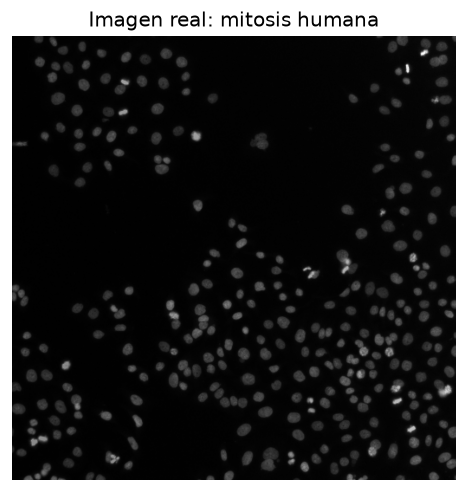

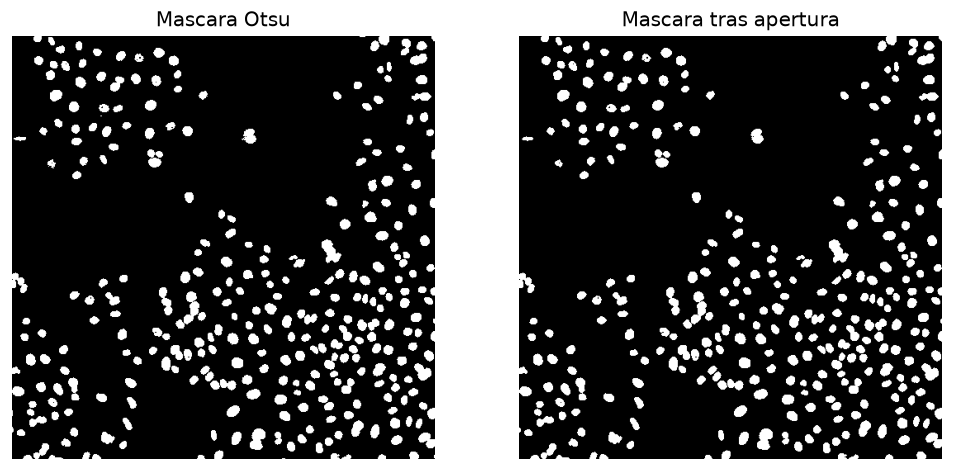

Numero de celulas detectadas: 290
Area media: 101.65172413793104
Compacticidad media: 0.9738507875856769


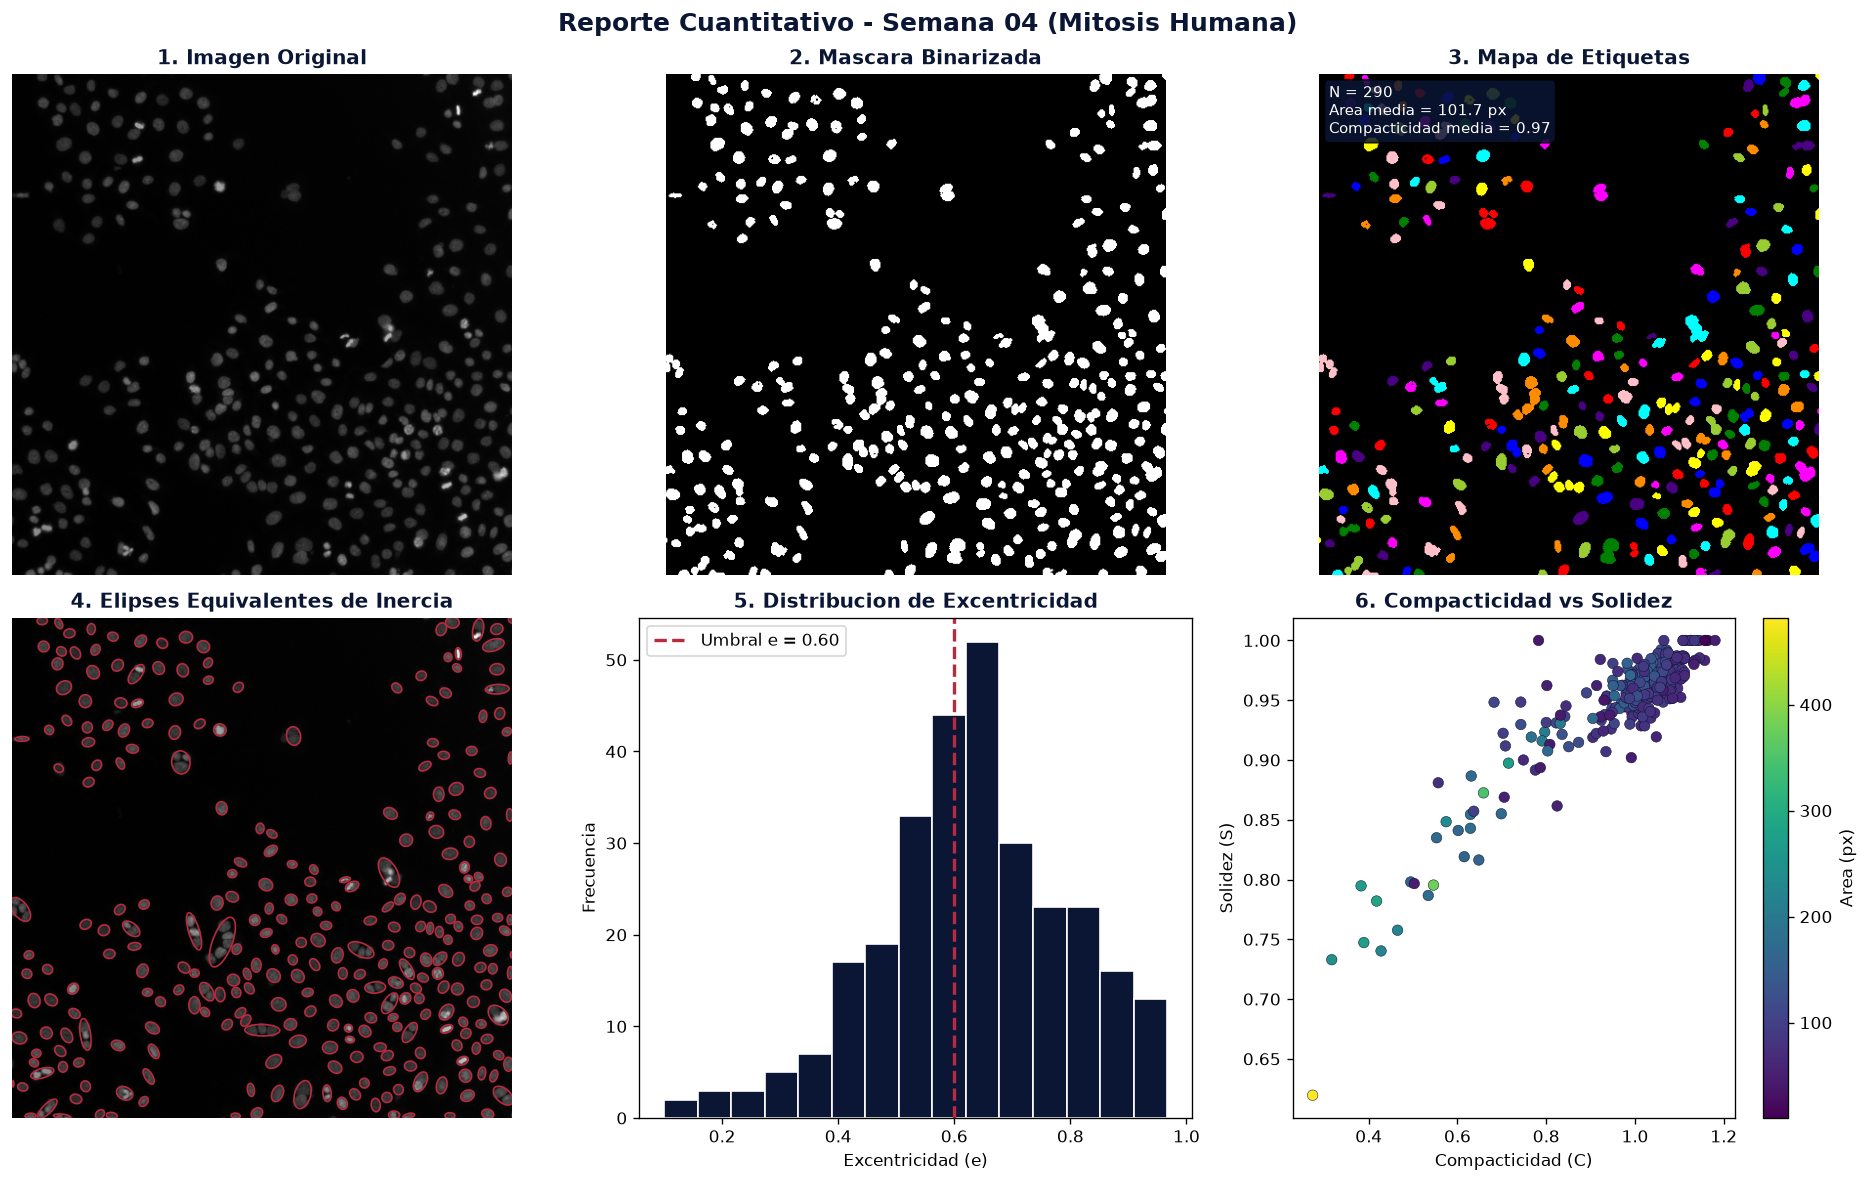

In [164]:
# Resolución ejercicio 5.

# Paso 1: Cargar imagen mitosis_humana.png en escala de grises.
imagen_mitosis = cv2.imread('imagenes/mitosis_humana.png', cv2.IMREAD_GRAYSCALE)
print("Tamano de la imagen:", imagen_mitosis.shape)
plt.imshow(imagen_mitosis, cmap='gray')
plt.title('Imagen real: mitosis humana')
plt.axis('off')
plt.show()

# Paso 2: se binariza la imagen usando el metodo de Otsu, que encuentra automaticamente el umbral que mejor separa las celulas del fondo.
_, mascara_binaria_mitosis = cv2.threshold(imagen_mitosis, 0, 255,
                                             cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel_eliptico = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
mascara_limpia_mitosis = cv2.morphologyEx(mascara_binaria_mitosis, cv2.MORPH_OPEN, kernel_eliptico)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(mascara_binaria_mitosis, cmap='gray')
ax[0].set_title('Mascara Otsu')
ax[0].axis('off')
ax[1].imshow(mascara_limpia_mitosis, cmap='gray')
ax[1].set_title('Mascara tras apertura')
ax[1].axis('off')
plt.show()

# Paso 3: se etiqueta cada region conectada de la mascara y luego se calculan sus propiedades geometricas.
etiquetas_mitosis = measure.label(mascara_limpia_mitosis // 255, connectivity=2)
propiedades_mitosis = measure.regionprops(etiquetas_mitosis)
total_celulas_mitosis = len(propiedades_mitosis)
print("Numero de celulas detectadas:", total_celulas_mitosis)

# Paso 4: para cada celula detectada se calcula su compacticidad, y se guardan tambien sus valores de excentricidad, solidez y area.
circularidades_mitosis = []
excentricidades_mitosis = []
solideces_mitosis = []
areas_mitosis = []

for celula in propiedades_mitosis:
    if celula.perimeter > 0:
        compacticidad = (4 * np.pi * celula.area) / (celula.perimeter ** 2)
    else:
        compacticidad = 0

    circularidades_mitosis.append(compacticidad)
    excentricidades_mitosis.append(celula.eccentricity)
    solideces_mitosis.append(celula.solidity)
    areas_mitosis.append(celula.area)

# Se calcula el area promedio y la compacticidad promedio de todas las celulas.
area_media_mitosis = np.mean(areas_mitosis)
compacticidad_media_mitosis = np.mean(circularidades_mitosis)

print("Area media:", area_media_mitosis)
print("Compacticidad media:", compacticidad_media_mitosis)

# Paso 5: Se arma la figura final.

fig, ax = plt.subplots(2, 3, figsize=(16, 10))

# Paso 5.1: panel 1, la imagen original en escala de grises
ax[0, 0].imshow(imagen_mitosis, cmap='gray')
ax[0, 0].set_title('1. Imagen Original', fontweight='bold', color=PRIS_NAVY)
ax[0, 0].axis('off')

# Paso 5.2: panel 2, la mascara binarizada despues de la apertura morfologica
ax[0, 1].imshow(mascara_limpia_mitosis, cmap='gray')
ax[0, 1].set_title('2. Mascara Binarizada', fontweight='bold', color=PRIS_NAVY)
ax[0, 1].axis('off')

# Paso 5.3: panel 3, el mapa de etiquetas a colores, con un cuadro de texto
# que resume el numero de celulas, el area media y la compacticidad media
mapa_coloreado = color.label2rgb(etiquetas_mitosis, bg_label=0)
ax[0, 2].imshow(mapa_coloreado)
ax[0, 2].set_title('3. Mapa de Etiquetas', fontweight='bold', color=PRIS_NAVY)
ax[0, 2].axis('off')

texto_resumen = (f"N = {total_celulas_mitosis}\n"
                  f"Area media = {area_media_mitosis:.1f} px\n"
                  f"Compacticidad media = {compacticidad_media_mitosis:.2f}")
ax[0, 2].text(0.02, 0.98, texto_resumen, transform=ax[0, 2].transAxes,
              fontsize=9, verticalalignment='top', color='white',
              bbox=dict(boxstyle='round', facecolor=PRIS_NAVY, alpha=0.85))

# Paso 5.4: panel 4, las elipses equivalentes de inercia dibujadas
# sobre la imagen original, una por cada celula detectada
ax[1, 0].imshow(imagen_mitosis, cmap='gray')
for celula in propiedades_mitosis:
    cy, cx = celula.centroid
    elipse = Ellipse((cx, cy), width=celula.axis_minor_length, height=celula.axis_major_length,
                      angle=-np.degrees(celula.orientation), edgecolor=PRIS_RED,
                      facecolor='none', linewidth=1.0)
    ax[1, 0].add_patch(elipse)
ax[1, 0].set_title('4. Elipses Equivalentes de Inercia', fontweight='bold', color=PRIS_NAVY)
ax[1, 0].axis('off')

# Paso 5.5: panel 5, un histograma con la distribucion de excentricidad
# de todas las celulas, marcando la linea del umbral e = 0.60
ax[1, 1].hist(excentricidades_mitosis, bins=15, color=PRIS_NAVY, edgecolor='white')
ax[1, 1].axvline(0.60, color=PRIS_RED, linestyle='--', linewidth=2, label='Umbral e = 0.60')
ax[1, 1].set_xlabel('Excentricidad (e)')
ax[1, 1].set_ylabel('Frecuencia')
ax[1, 1].set_title('5. Distribucion de Excentricidad', fontweight='bold', color=PRIS_NAVY)
ax[1, 1].legend()

# Paso 5.6: panel 6, un diagrama de dispersion de compacticidad contra
# solidez, coloreando cada punto segun el area de la celula
disp = ax[1, 2].scatter(circularidades_mitosis, solideces_mitosis, c=areas_mitosis,
                         cmap='viridis', s=40, edgecolor=PRIS_NAVY, linewidth=0.3)
ax[1, 2].set_xlabel('Compacticidad (C)')
ax[1, 2].set_ylabel('Solidez (S)')
ax[1, 2].set_title('6. Compacticidad vs Solidez', fontweight='bold', color=PRIS_NAVY)
plt.colorbar(disp, ax=ax[1, 2], label='Area (px)')

# Paso 5.7: titulo general y guardado de la figura final
plt.suptitle('Reporte Cuantitativo - Semana 04 (Mitosis Humana)', fontsize=15,
              fontweight='bold', color=PRIS_NAVY)
plt.tight_layout()
plt.savefig('reporte_semana04.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Rúbrica de Evaluación

| Ejercicio | Puntos | Criterio |
|:----------|:------:|:---------|
| **Ej. 1: Two-Pass CCL + Union-Find** | **25** | Implementación manual correcta, manejo de vecindad causal (4 u 8) y resolución canónica de equivalencias. |
| **Ej. 2: Pipeline Drepanocitosis** | **25** | Generación de frotis, segmentación de Otsu + apertura, extracción de $e$ y clasificación discocitos vs. drepanocitos. |
| **Ej. 3: Calibración Espacial Biomédica** | **15** | Investigación de modalidad clínica real (OCT, $\mu$-CT, STED), especificaciones ($s$, FOV) y cálculo físico riguroso en $\mu\text{m}^2$. |
| **Ej. 4: Morfometría Multi-Escala** | **15** | Análisis cuantitativo del impacto de la resolución sobre la compacticidad ($C$) y determinación del límite de fiabilidad. |
| **Ej. 5: Reporte Cuantitativo Profesional** | **20** | Visualización clínica en 6 paneles con elipses equivalentes, histograma de $e$, scatter $C$ vs $S$, y cuadro de estadísticas. |
| **Total** | **100** | |

**Bonificación (+10 puntos):** Generalizar el Two-Pass CCL con soporte de conectividad parametrizable (4 u 8) o realizar un benchmark de tiempo de cómputo frente a BBDT (`cv2.CCL_BBDT`).